SCS 3546: Deep Learning
> Assignment 2: Convolutional Neural Nets and Transfer Learning

### Your name & student number:

<pre> Cameron Turner </pre>

<pre> X606793 </pre>

**Note**: Make sure you are using a GPU for processing.  Change it in the Runtime Type.

In [54]:
# Import Tensorflow libraries.

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Input, Dense, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.utils import image_dataset_from_directory
from keras.models import Sequential

# Import Sklearn libraries.

from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Import data science and visualization libraries.

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Turn off warnings.

import warnings
#warnings.filterwarnings("ignore")


In [55]:
# mount the colab
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [56]:
!ls "/content/drive/MyDrive/flower_photos.tgz"

/content/drive/MyDrive/flower_photos.tgz


In [58]:
import os
os.listdir('/content/drive/MyDrive')

['PersonalContacts.gsheet',
 'PowerApps',
 'Consultants.gsheet',
 'Untitled spreadsheet.gsheet',
 '.ipynb_checkpoints',
 'Colab Notebooks',
 'y_train.csv',
 'y_test.csv',
 'X_train.csv',
 'X_test.csv',
 '03_Convolutional_Neural_Networks.ipynb',
 'flower_photos.tgz',
 'flower_photos',
 'P_SCS 3546_Activity 3.1.ipynb']

In [59]:
# Set the directory that contains the photos.

data_dir = "/content/drive/MyDrive/flower_photos"


In [60]:
# Set variables used throughout the assignment.

batch_size = 32
img_height = 224
img_width = 224

num_epochs = 10  # Use a small number to start to speed training

In [61]:
# Create the training data from the dataset.

train_ds = image_dataset_from_directory(
                  data_dir,
                  validation_split=0.2,
                  subset="training",
                  seed=123,
                  image_size=(img_height, img_width),
                  batch_size=batch_size)


Found 3670 files belonging to 5 classes.
Using 2936 files for training.


In [62]:
# Create the validation data from the dataset.

validation_ds = image_dataset_from_directory(
                  data_dir,
                  validation_split=0.2,
                  subset="validation",
                  seed=123,
                  image_size=(img_height, img_width),
                  batch_size=batch_size)


Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [63]:
# Print out the class names of the training set.

train_class_names = train_ds.class_names
print(train_class_names)

# Print out the class names of the validation set.  They should of course be the same!

validation_class_names = train_ds.class_names
print(validation_class_names)


['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [64]:
# print_dataset_distribution

def print_dataset_distribution(nn_ds):

    ds_class_names = nn_ds.class_names
    ds_name_hash = {}

    # Initialize a hashmap of unique class names from the dataset.

    for class_name in ds_class_names:
        ds_name_hash[class_name] = 0

    # Calculate the number of records in the dataset.

    num_records = len(nn_ds) * batch_size
    print("There are", num_records, "records in the dataset.  The distribution is as follows:")

    # Iterate over the dataset.

    for images, labels in nn_ds:

        # Iterate over the labels and increment the label's hashmap counter.

        for label in labels.numpy():
            ds_name_hash[ds_class_names[label]] += 1

    # Print out the unique class names from the dataset along with their frequency.

    for class_name in ds_class_names:
      print(f"{class_name:15} -> {ds_name_hash[class_name]:5} (", round(((ds_name_hash[class_name]/num_records)*100), 0), "%)")

In [65]:
# Print out the frequency of the training dataset.

print_dataset_distribution(train_ds)

There are 2944 records in the dataset.  The distribution is as follows:
daisy           ->   504 ( 17.0 %)
dandelion       ->   722 ( 25.0 %)
roses           ->   521 ( 18.0 %)
sunflowers      ->   547 ( 19.0 %)
tulips          ->   642 ( 22.0 %)


In [66]:
# Print out the frequency of the validation dataset.

print_dataset_distribution(validation_ds)

There are 736 records in the dataset.  The distribution is as follows:
daisy           ->   129 ( 18.0 %)
dandelion       ->   176 ( 24.0 %)
roses           ->   120 ( 16.0 %)
sunflowers      ->   152 ( 21.0 %)
tulips          ->   157 ( 21.0 %)


Distribution between Training and Validation data sets is good!

Now, display a set of the data to get an idea of the photos in the dataset.

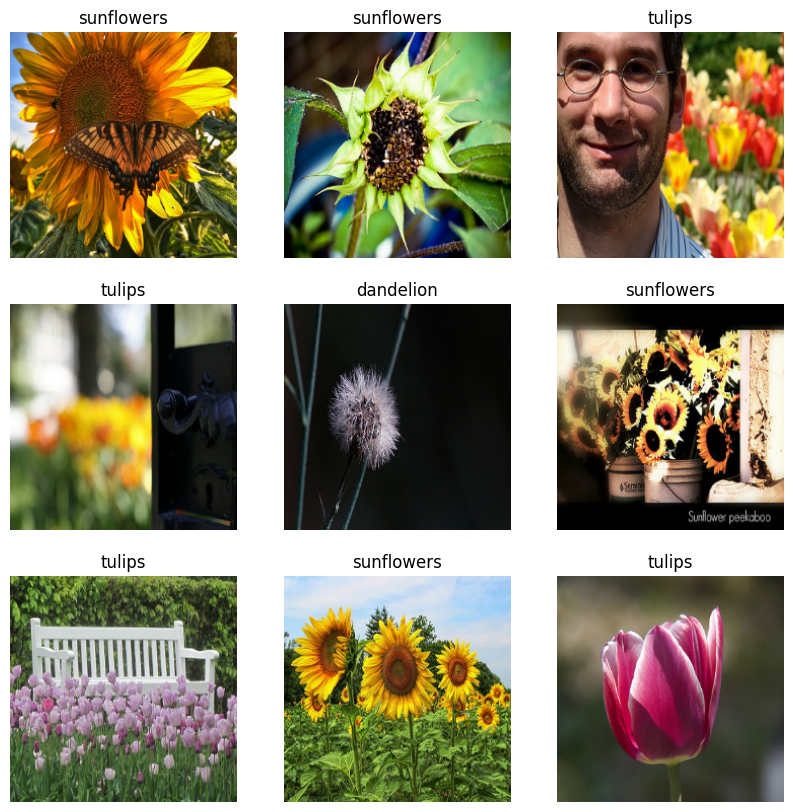

In [67]:

plt.figure(figsize=(10, 10))

# Iterate over the training data set and plot the images
# and labels of the first 15 photos.

for images, labels in train_ds.take(1):

  # Just look at the first 9 photos (9 being the limit!).

  for i in range(9):

    # Plot the photo with the label.

    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(train_class_names[labels[i]])
    plt.axis("off")


In [68]:
# Apply image preprocessing and prefetching to increase performance.

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
validation_ds = validation_ds.map(lambda x, y: (preprocess_input(x), y))

train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
validation_ds = validation_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

In [69]:
# Define common functions.


# load_base_model

def load_base_model():

    # Load base model without fully connected layers (include_top = False).
    # Use a VGG16 model (pre-trained on ImageNet) for transfer learning.
    # Remove the top layers (fully connected layers).

    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(img_height, img_width, 3)  # 3 channels
    )

    return base_model


# run_neural_net

def run_neural_net(base_model, num_layers, num_neurons, activation_fn, num_epochs, lr):

    # Create the Sequential neural net with the base model, hidden layers/neurons/activation function
    # and the output layer.

    model = keras.Sequential()
    model.add(base_model)
    model.add(layers.GlobalAveragePooling2D())

    # Iterate over the number of layers specified and add the number of
    # neurons provided.

    for i in range(num_layers):
      model.add(layers.Dense(num_neurons, activation=activation_fn))
      model.add(layers.Dropout(0.5))

    # Add the output layer to the model with the softmax activation function.
    # The output activation function should be different than the hidden
    # layers activation function.

    model.add(layers.Dense(5, activation='softmax'))

    # Compile the model using the Adam optimizer with a learning rate
    # (typically the default, 0.001, passed in) and use the crossentropy loss
    # and accuracy metric (i.e., since it's a classification problem vs a regression problem).

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Fit the model using the training features (X_train), training targets (y_train).
    # Validate the model with the validation data (X_valid, y_valid).

    history = model.fit(
        train_ds,
        epochs=num_epochs,
        validation_data=validation_ds,
        verbose=1
    )

    # Return the model and the history.

    return model, history


# evaluate_model

def evaluate_model(model, validation_ds):

    # Evaluate the model and get the results.
    # Loss will be in the first array cell, accuracy in the second.

    model_results = model.evaluate(validation_ds)
    print("Validation Loss:", model_results[0])
    print("Validation Accuracy:", model_results[1])


# plot_loss

def plot_loss(history):

    # Plot the Loss values for the model training (over the epochs).

    plt.plot(history.history['loss'], label='Loss - Training Data')
    plt.plot(history.history['val_loss'], label='Loss - Validation Data')
    plt.legend()
    plt.show()


# plot_accuracy

def plot_accuracy(history):

    # Plot the Accuracy values for the model training (over the epochs).

    plt.plot(history.history['accuracy'], label='Accuracy - Training Data')
    plt.plot(history.history['val_accuracy'], label='Accuracy - Validation Data')
    plt.legend()
    plt.show()



**Model 1: Case 1**

Let's start with 1 layer of 256 neurons using the ReLU activation function and a default learning rate and see what that gets us.

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 30s 282ms/step - accuracy: 0.6638 - loss: 1.9159 - val_accuracy: 0.8583 - val_loss: 0.4449
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 254ms/step - accuracy: 0.8168 - loss: 0.5620 - val_accuracy: 0.8787 - val_loss: 0.3753
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 230ms/step - accuracy: 0.8655 - loss: 0.4047 - val_accuracy: 0.8924 - val_loss: 0.3322
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 248ms/step - accuracy: 0.8944 - loss: 0.3043 - val_accuracy: 0.8883 - val_loss: 0.3305
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 245ms/step - accuracy: 0.9128 - loss: 0.2371 - val_accuracy: 0.8965 - val_loss: 0.3152
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 246ms/step - accuracy: 0.9281 - loss: 0.2082 - val_accuracy: 0.9033 - val_loss: 0.2937
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 235ms/step - accuracy: 0.9411 - loss: 0.1567 - val_accuracy: 0.8951 - val_loss: 0.3268
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 242ms/step - accuracy: 0.9537 - loss: 0.1375 - val_accu

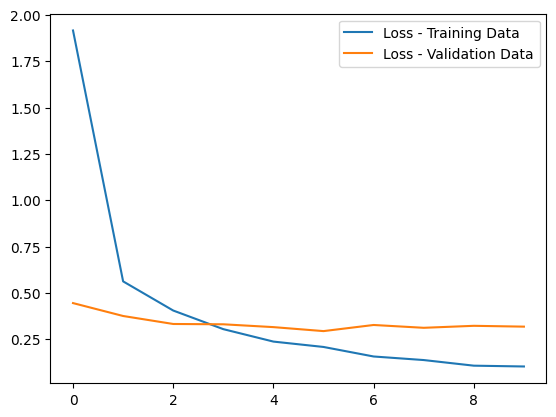

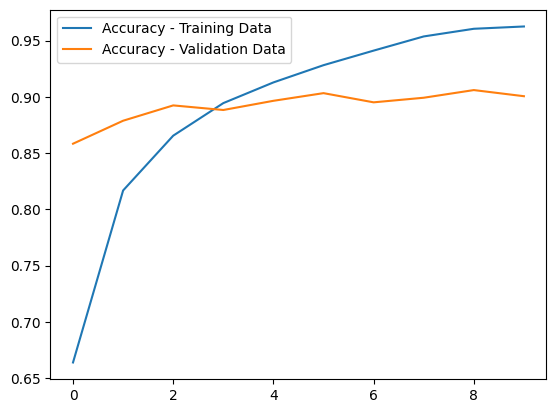

In [70]:
# Load the base neural net model.

base_model = load_base_model()

# Set the base model as 'untrainable' to freeze the convolutional base.
# This way the model is trained with only the layers that are added below.

base_model.trainable = False

# Run the neural net model with 1 layer of 256 neurons and the ReLU activation function.

model, history = run_neural_net(base_model, 1, 256, 'relu', num_epochs, 0.001)

# Evaluate the neural net model.

evaluate_model(model, validation_ds)

# Plot the loss and accuracy graphs to show a visual depiction
# of learning over the epochs.

plot_loss(history)

plot_accuracy(history)



Excellent overall accuracy that gets better as the epochs progress but validation accuracy is relatively wide.  Perhaps overfitting after epoch 6?

**Model 1: Case 2**

Let's now reduce the number of neurons to 16 neurons (less neurons than Case 1) using the ReLU activation function and a default learning rate.

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 30s 270ms/step - accuracy: 0.3219 - loss: 2.0483 - val_accuracy: 0.4605 - val_loss: 1.2865
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 244ms/step - accuracy: 0.3927 - loss: 1.3538 - val_accuracy: 0.6172 - val_loss: 1.0196
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 247ms/step - accuracy: 0.4928 - loss: 1.1519 - val_accuracy: 0.6798 - val_loss: 0.8265
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 235ms/step - accuracy: 0.5521 - loss: 0.9884 - val_accuracy: 0.7275 - val_loss: 0.7273
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 245ms/step - accuracy: 0.6196 - loss: 0.8835 - val_accuracy: 0.7793 - val_loss: 0.6380
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 41s 249ms/step - accuracy: 0.6274 - loss: 0.8232 - val_accuracy: 0.7997 - val_loss: 0.5704
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 250ms/step - accuracy: 0.6666 - loss: 0.7436 - val_accuracy: 0.8120 - val_loss: 0.5312
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 248ms/step - accuracy: 0.6679 - loss: 0.7369 - val_accu

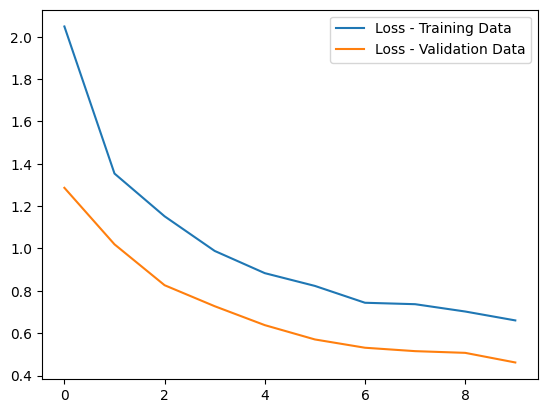

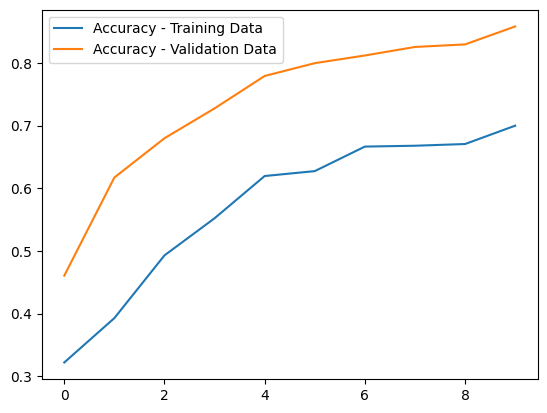

In [71]:
# Run the neural net model with 1 layer of 16 neurons and the ReLU activation function.

model, history = run_neural_net(base_model, 1, 16, 'relu', num_epochs, 0.001)

# Evaluate the neural net model.

evaluate_model(model, validation_ds)

# Plot the loss and accuracy graphs to show a visual depiction
# of learning over the epochs.

plot_loss(history)

plot_accuracy(history)


Slightly less accuracy than Case 1 where there were more neurons in 1 layer but the model is still learning quite well as accuracy and validation increases as the epochs progress.  Validation accuracy is about 16% higher than training accuracy which may be due to the dropout rate of 50% of neurons.

**Model 1: Case 3**

Let's add another layer - 2 layers of 64 neurons using the ReLU activation function and the default learning rate.

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 30s 282ms/step - accuracy: 0.3604 - loss: 2.6195 - val_accuracy: 0.6322 - val_loss: 1.0757
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 238ms/step - accuracy: 0.4785 - loss: 1.2806 - val_accuracy: 0.7343 - val_loss: 0.8190
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 247ms/step - accuracy: 0.5882 - loss: 1.0328 - val_accuracy: 0.7711 - val_loss: 0.6973
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 233ms/step - accuracy: 0.6505 - loss: 0.9391 - val_accuracy: 0.7847 - val_loss: 0.6518
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 245ms/step - accuracy: 0.6890 - loss: 0.8323 - val_accuracy: 0.8106 - val_loss: 0.5834
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 236ms/step - accuracy: 0.7415 - loss: 0.7020 - val_accuracy: 0.8406 - val_loss: 0.5237
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 240ms/step - accuracy: 0.7698 - loss: 0.6346 - val_accuracy: 0.8529 - val_loss: 0.4473
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 244ms/step - accuracy: 0.7762 - loss: 0.6152 - val_accu

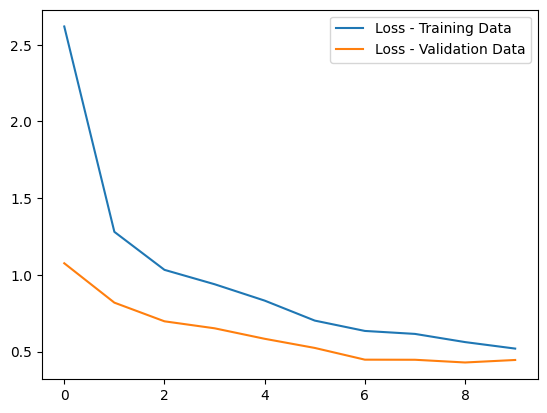

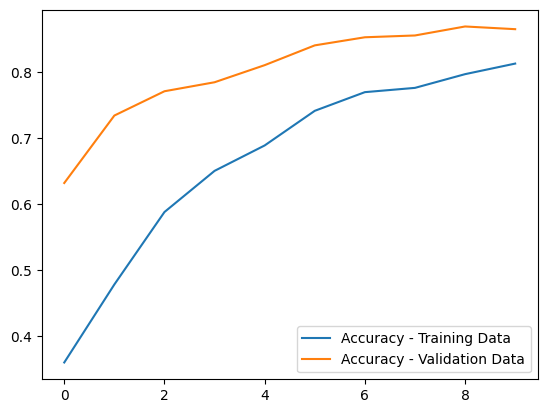

In [72]:
# Run the neural net model with 2 layers of 64 neurons each and the ReLU activation function.

model, history = run_neural_net(base_model, 2, 64, 'relu', num_epochs, 0.001)

# Evaluate the neural net model.

evaluate_model(model, validation_ds)

# Plot the loss and accuracy graphs to show a visual depiction
# of learning over the epochs.

plot_loss(history)

plot_accuracy(history)


Adding another layer with more neurons improves the accuracy.  Validation accuracy is closer to training accuracy so the model may be better generalizing by having another layer.

**Model 1: Case 4**

Let's double the layers to 4 layers and 256 neurons (more neurons) using the ReLU activation function and default learning rate.

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 33s 293ms/step - accuracy: 0.3106 - loss: 2.5880 - val_accuracy: 0.6621 - val_loss: 1.1009
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 248ms/step - accuracy: 0.5106 - loss: 1.2636 - val_accuracy: 0.7357 - val_loss: 0.7850
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 239ms/step - accuracy: 0.6373 - loss: 0.9372 - val_accuracy: 0.7875 - val_loss: 0.6111
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 243ms/step - accuracy: 0.7193 - loss: 0.7462 - val_accuracy: 0.8474 - val_loss: 0.4972
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 243ms/step - accuracy: 0.7599 - loss: 0.6372 - val_accuracy: 0.8597 - val_loss: 0.4721
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 253ms/step - accuracy: 0.7960 - loss: 0.5573 - val_accuracy: 0.8706 - val_loss: 0.4128
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 28s 305ms/step - accuracy: 0.8253 - loss: 0.4858 - val_accuracy: 0.8651 - val_loss: 0.4168
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 250ms/step - accuracy: 0.8403 - loss: 0.4394 - val_accu

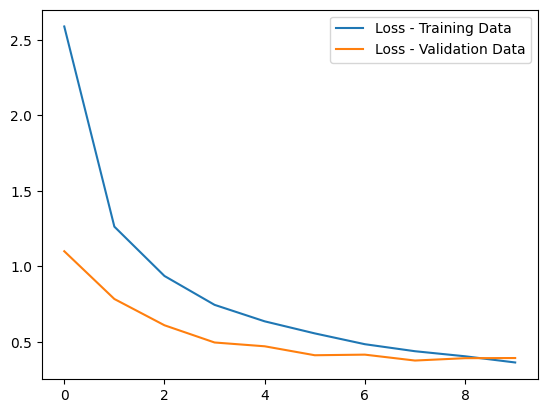

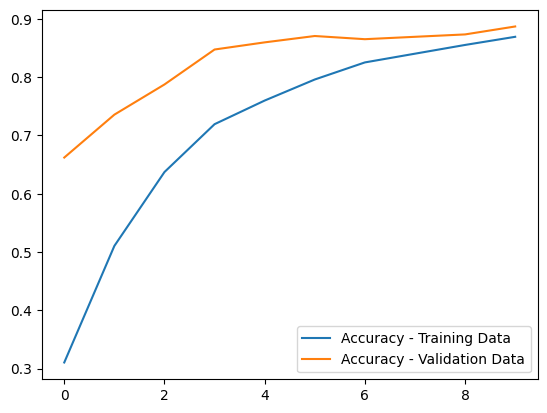

In [73]:
# Run the neural net model with 4 layers of 256 neurons each and the ReLU activation function.

model, history = run_neural_net(base_model, 4, 256, 'relu', num_epochs, 0.001)

# Evaluate the neural net model.

evaluate_model(model, validation_ds)

# Plot the loss and accuracy graphs to show a visual depiction
# of learning over the epochs.

plot_loss(history)

plot_accuracy(history)


Having 4 layers and 256 neurons provides excellent accuracy and the validation data is very close.  4 Layers with 256 neurons is the winner so far.

**Model 1: Case 5**

Case 5 consists of 16 layers (more layers) of 256 neurons (more neurons) using the ReLU activation function.

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 52s 408ms/step - accuracy: 0.2153 - loss: 2.0000 - val_accuracy: 0.2398 - val_loss: 1.6058
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 245ms/step - accuracy: 0.2439 - loss: 1.6216 - val_accuracy: 0.2398 - val_loss: 1.6039
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 261ms/step - accuracy: 0.2626 - loss: 1.6101 - val_accuracy: 0.2398 - val_loss: 1.6048
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 28s 307ms/step - accuracy: 0.2939 - loss: 1.5934 - val_accuracy: 0.2398 - val_loss: 1.6099
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 249ms/step - accuracy: 0.3294 - loss: 1.5576 - val_accuracy: 0.2398 - val_loss: 1.6413
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 243ms/step - accuracy: 0.3825 - loss: 1.4507 - val_accuracy: 0.2398 - val_loss: 1.7686
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 254ms/step - accuracy: 0.4172 - loss: 1.3230 - val_accuracy: 0.2398 - val_loss: 1.9469
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 238ms/step - accuracy: 0.4475 - loss: 1.2289 - val_accu

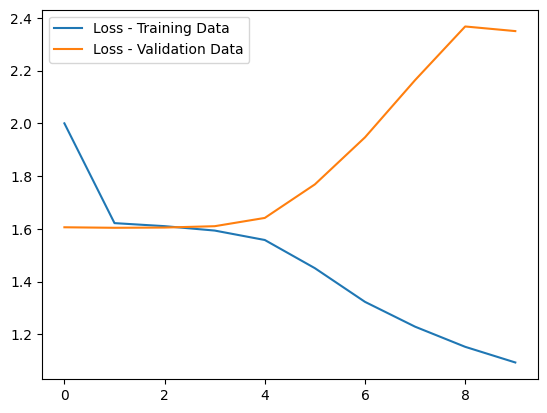

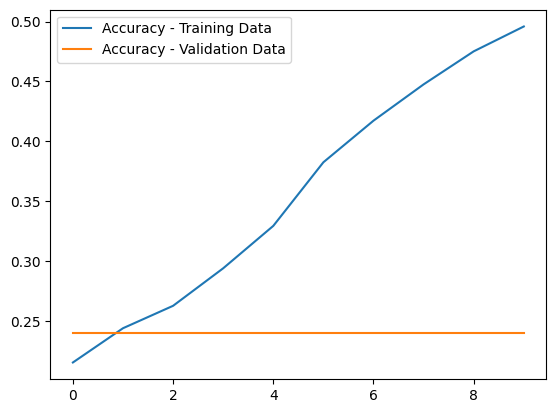

In [74]:
# Run the neural net model with 4 layers of 256 neurons each and the ReLU activation function.

model, history = run_neural_net(base_model, 16, 256, 'relu', num_epochs, 0.001)

# Evaluate the neural net model.

evaluate_model(model, validation_ds)

# Plot the loss and accuracy graphs to show a visual depiction
# of learning over the epochs.

plot_loss(history)

plot_accuracy(history)

Accuracy and loss are unstable and don't show the results we're looking for.  This might be too many layers and too many neurons for the size of the dataset.  As the model was fine in the previous runs, perhaps it's a data issue.

**Model 1 Summary**  

Over the course of the epochs, most of the Model 1 test cases all seem to have good learning rates (except for Case 5).  The accuracy increases over the epochs with greatest learning over the first couple of epochs.  After which, the learning rate increases but at a smaller rate.

The Loss, on the other hand, steadily decreases with the greatest decrease over the first epoch.  This would be expected based on the accuracy.

The configuration with the best performance is: 4 layers of 256 neurons with the ReLu activation function.  This has the best overall accuracy for this dataset.

**Model 2**

This model will unfreeze the last block of VGG16 (block5).  We will use a hyperparameter configuration of 2 layers and 64 neurons and a very low learning rate.

In [75]:
# Ensure convolutional base is still frozen.

base_model.trainable = False

# Iterate over the base model layers.

for layer in base_model.layers:

    print (layer.name)

    # Unfreeze the last block - block5.

    if (layer.name.startswith("block5")):
        layer.trainable = True


input_layer_17
block1_conv1
block1_conv2
block1_pool
block2_conv1
block2_conv2
block2_pool
block3_conv1
block3_conv2
block3_conv3
block3_pool
block4_conv1
block4_conv2
block4_conv3
block4_pool
block5_conv1
block5_conv2
block5_conv3
block5_pool


Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 34s 312ms/step - accuracy: 0.2721 - loss: 2.7640 - val_accuracy: 0.3910 - val_loss: 1.4619
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 266ms/step - accuracy: 0.2994 - loss: 1.6538 - val_accuracy: 0.4346 - val_loss: 1.4249
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 254ms/step - accuracy: 0.3375 - loss: 1.5243 - val_accuracy: 0.5082 - val_loss: 1.3393
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 258ms/step - accuracy: 0.3685 - loss: 1.4320 - val_accuracy: 0.5695 - val_loss: 1.2203
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 269ms/step - accuracy: 0.4172 - loss: 1.3592 - val_accuracy: 0.6158 - val_loss: 1.1171
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 262ms/step - accuracy: 0.4401 - loss: 1.2904 - val_accuracy: 0.6499 - val_loss: 1.0227
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 267ms/step - accuracy: 0.4806 - loss: 1.2253 - val_accuracy: 0.6757 - val_loss: 0.9469
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 265ms/step - accuracy: 0.5160 - loss: 1.1334 - val_accu

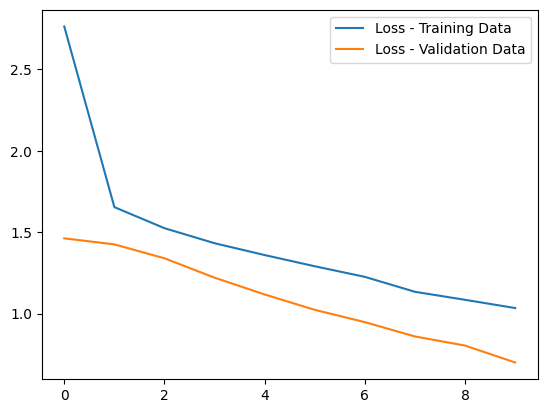

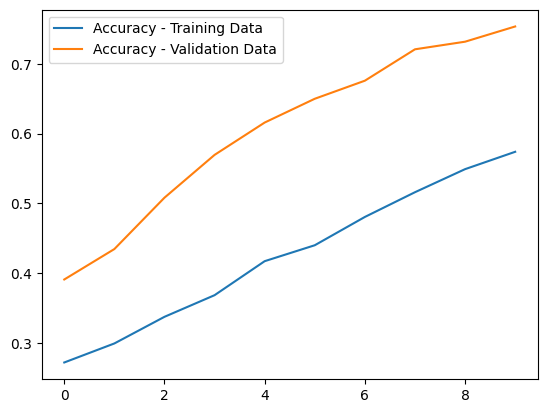

In [76]:
# Run the neural net model with 2 layers of 64 neurons and the ReLU activation function.

model, history = run_neural_net(base_model, 2, 64, 'relu', num_epochs, 1e-5)

# Evaluate the neural net model.

evaluate_model(model, validation_ds)

# Plot the loss and accuracy graphs to show a visual depiction
# of learning over the epochs.

plot_loss(history)

plot_accuracy(history)


**Model 2 Summary**

Accuracy is lower than Model 1 and the validation accuracy is nowhere near the training accuracy.  Therefore, the Model seems to be underfitting.  Perhaps only having 64 neurons in two layers over 10 epochs is not enough time for the model to learn.  Afterall, the accuracy values are still increasing.  Perhaps increasing to 20 epochs, increasing the layers and neurons may have a better result.



**Model 3**

Unfreeze all the layers and re-evaluate.

Trainable: block5_conv1
Trainable: block5_conv2
Trainable: block5_conv3
Trainable: block5_pool
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 38s 346ms/step - accuracy: 0.2098 - loss: 1.8458 - val_accuracy: 0.2520 - val_loss: 1.5241
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 30s 261ms/step - accuracy: 0.2231 - loss: 1.5590 - val_accuracy: 0.3270 - val_loss: 1.4287
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 270ms/step - accuracy: 0.2704 - loss: 1.5035 - val_accuracy: 0.4510 - val_loss: 1.3504
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 41s 268ms/step - accuracy: 0.3157 - loss: 1.4541 - val_accuracy: 0.5545 - val_loss: 1.2640
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 272ms/step - accuracy: 0.3535 - loss: 1.3999 - val_accuracy: 0.6226 - val_loss: 1.1591
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 254ms/step - accuracy: 0.4057 - loss: 1.3263 - val_accuracy: 0.6962 - val_loss: 1.0261
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 264ms/step - accuracy: 0.4619 - loss: 1.2328 - val_accuracy: 0.7725 - val_loss: 0.8898
Ep

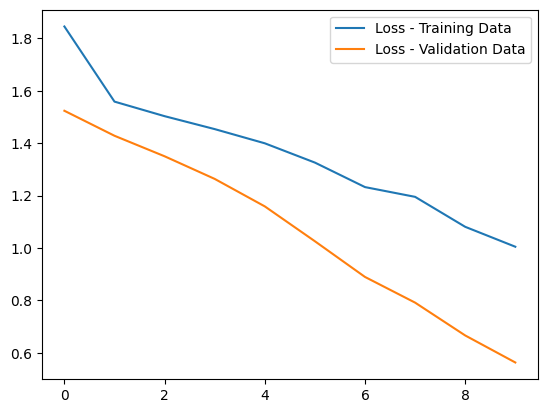

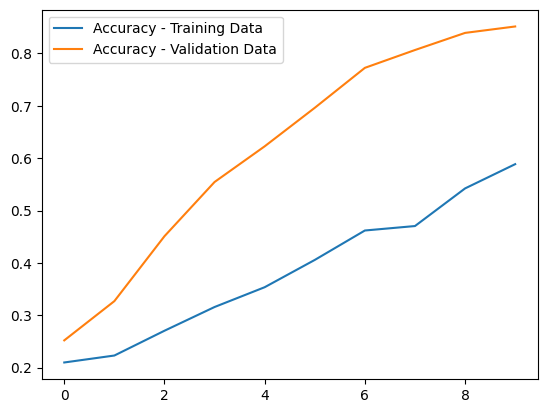

In [ ]:
for layer in base_model.layers:
    
    # Set the layer to be trainable.

    layer.trainable = True

    # Just to be sure...
    
    if layer.trainable:
        print("Trainable:", layer.name)

# Run the neural net model with 2 layer of 64 neurons and the ReLU activation function.

model, history = run_neural_net(base_model, 2, 64, 'relu', num_epochs, 1e-5)

# Evaluate the neural net model.

evaluate_model(model, validation_ds)

# Plot the loss and accuracy graphs to show a visual depiction
# of learning over the epochs.

plot_loss(history)

plot_accuracy(history)


**Model 3 Summary**

The accuracy is similar to Model 1 and better than Model 2.  Similar to Model 2, this model may be better trained over a larger number of epochs, neurons and layers.  The gap between training and validation is most likely due to 50% of neurons being dropped during training.  However, unfreezing layers allows the model to adapt to these high-level features.


**Summary**

In Summary, all three models provide excellent performance showing increases in accuracy as learning over the epochs progress.  Unfreezing layers allows for fine-tuning the model for high-level features.  Therefore, by increasing the number of epochs, layers and neurons, it is expected that Model 3 would provide the best results for the Convolutional Neural Network (CNN).